In [5]:
import numpy as np
import pandas as pd
import os
import sys
import country_converter as coco

parent_dir = os.path.abspath("..")
sys.path.insert(0, parent_dir)

import numpy as np
import pandas as pd

from experiments import utils
from package_name.evaluation import plots as eval_plots
from package_name.evaluation.utils import predict_clusters
from package_name.evaluation import metrics
from package_name.training.trainer import VAETrainer, VAEConfig
from package_name.tuning.cross_validator import CrossValidator
from package_name.inference.predictor import VAEPredictor
from package_name.model.utils import sampling


import matplotlib.pyplot as plt
import plotly.express as px
plt.style.use("dark_background")



## Parameters

In [2]:
g0 = 9.80665
extended_winter_months = [11, 12, 1, 2, 3]
results_path = "results/energy/"
data_path = "data/wind/"
cluster_number = 4
original_dim = 575
pr_cluster_number = 4
batch_size = 128
epochs = 500


## Data loading and pre-processing

In [3]:
# #create clusters for country-wise energy data
# path = data_path + "WON_country_wise.csv"

# df_in = pd.read_csv(path, comment="#")

# df_filtered = df_in.copy()
# df_filtered["Date"] = pd.to_datetime(df_filtered["Date"])
# df_filtered = df_filtered[(df_filtered["Date"].dt.year > 1980) & (df_filtered["Date"].dt.year < 2023)]
# df_filtered = df_filtered[df_filtered["Date"].dt.month.isin(extended_winter_months)]

# df_countries = df_filtered.drop(columns=["Date"])
# df_countries = df_countries.dropna(axis=1, how="all").reset_index(drop=True)

# df_norm, df_clusters = utils.cluster_country_wise(df_countries, cluster_number=pr_cluster_number, standardize=True)

# df_clusters.to_csv(data_path + "WON_clusters_norm.csv")
# df_norm.to_csv(data_path + "WON_country_wise_norm.csv")

df_clusters = pd.read_csv(data_path + "WON_clusters_norm.csv", index_col=0)
df_norm = pd.read_csv(data_path + "WON_country_wise_norm.csv", index_col=0)

In [4]:
# Get training data
z500 = utils.preprocess_dataset(filename ='data/era5_z500_daily_250_atlantic_1940_2022.nc',
                             variable_name = 'z',
                             multiplication_factor = 1/g0,
                             geographical_filter = 'extended europe',
                             months_filter = extended_winter_months,
                             anomalies = True,
                             normalization = False,
                             rolling_window = 5)

z500 = z500.where(z500['time.year'] > 1980, drop=True)
z500 = z500.where(z500['time.year'] < 2023, drop=True)


weights = np.cos(np.deg2rad(z500.latitude))
z500 = z500*weights
z500 = z500/z500.std()

z500_reshaped = utils.reshape_data_for_clustering(z500)

# Get training data labels
pr_labels = pd.read_csv(data_path + 'WON_clusters_norm.csv')
pr_labels.columns = ['index', 'labels']
#pr_labels.drop(pr_labels.tail(1).index,inplace=True)

pr_labels['values']=[1]*len(pr_labels)
label_indices_pd = pd.pivot_table(pr_labels, values='values', index=['index'],
                    columns=['labels'], aggfunc=np.sum).fillna(0)
label_indices = label_indices_pd.values

## Visualise target clusters

In [5]:
#select days belonging to each cluster and calculate the mean of each cluster
df_cluster_means = pd.DataFrame(columns=df_norm.columns)
for i in range(4):
    cluster_i = df_norm[df_clusters["labels"] == i]
    cluster_i_mean = cluster_i.mean()
    df_cluster_means.loc[i] = cluster_i_mean

In [6]:
# TODO: turn this into a function
column_labels = df_norm.columns.astype(str).tolist()

plot_data_list = []
for cluster_id in range(4):
    df_temp = pd.DataFrame({
        'iso2_labels': column_labels,  
        'metric_value': df_cluster_means.loc[cluster_id].values,
        'cluster': f"K-means Cluster {cluster_id}" 
    })
    plot_data_list.append(df_temp)

df_plot = pd.concat(plot_data_list, ignore_index=True)

# Convert the ISO-2 labels column to ISO-3 strings
cc = coco.CountryConverter()
df_plot['iso3_labels'] = cc.convert(names=df_plot['iso2_labels'].tolist(), to='ISO3')

# Plot
fig = px.choropleth(
    df_plot,
    locations="iso3_labels",        
    locationmode="ISO-3",         
    color="metric_value",         
    hover_name="iso2_labels",    
    scope="europe",               
    facet_col="cluster",         
    color_continuous_scale=px.colors.sequential.Viridis, 
    title="European Energy Clusters"
)


fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1])) # Removes ugly "cluster=" prefix from subplot titles
fig.update_layout(
    margin={"r":10, "t":40, "l":10, "b":5},
    height=200, 
    width=600, 

    coloraxis_colorbar=dict(
        title="Wind CF anomaly",     
        thicknessmode="pixels",
        thickness=5,  
        orientation="h",          
        lenmode="fraction",
        len=0.5,              
        yanchor="middle",       
        y=-0.1
    )
)

fig.show()

## Define model

In [15]:
config = VAEConfig(
    original_dim=original_dim,
    original_dim_target=pr_cluster_number,
    dim_layer1=256,
    dim_layer2=128,
    dim_layer3=64,
    activation="relu",
    cluster_number=cluster_number,
    latent_dim=10,#8,
    pr_cluster_number=pr_cluster_number,
    sampling_fn=sampling,
)

loss_config = LossFactorsConfig(
    vae_reconstruction_loss_factor=1,
    vae_regularisation_loss_factor=1,
    target_prediction_loss_factor=1,
    cluster_target_regularisation_loss_factor=1,#5
    mixture_regularization_loss_factor=1,#2,
    dirichlet_loss_factor=0.5 #1
)

vae = VAETrainer(cfg=config,  path_to_save_weights=results_path, loss_factors=loss_config)
vae.compile()

history = vae.fit(
    X=z500.values,
    y=label_indices,
    epochs=epochs,
    batch_size=batch_size
)

vae.save_weights(results_path+'final_weights_'+str(cluster_number)+'.weights.h5')

Epoch 1/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - cluster_target_regularisation_loss: 0.1893 - mixture_regularization_loss: 2.8678 - reconstruction_loss: 501.9323 - target_prediction_loss: 6.0910 - total_loss: 522.9464 - vae_regularisation_loss: 11.8660 - val_cluster_target_regularisation_loss: 0.2917 - val_mixture_regularization_loss: 2.8371 - val_reconstruction_loss: 321.6606 - val_target_prediction_loss: 6.5469 - val_total_loss: 352.3810 - val_vae_regularisation_loss: 21.0447
Epoch 2/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - cluster_target_regularisation_loss: 0.2969 - mixture_regularization_loss: 2.8392 - reconstruction_loss: 258.7912 - target_prediction_loss: 6.0693 - total_loss: 289.0900 - vae_regularisation_loss: 21.0934 - val_cluster_target_regularisation_loss: 0.2860 - val_mixture_regularization_loss: 2.8356 - val_reconstruction_loss: 219.8083 - val_target_prediction_loss: 5.7409 - val_total_loss: 249.5795 - val_vae_regularisation_loss: 20.9088
Epoch 3/500
35/35 ━━━━━━━

## Plot training and validation losses

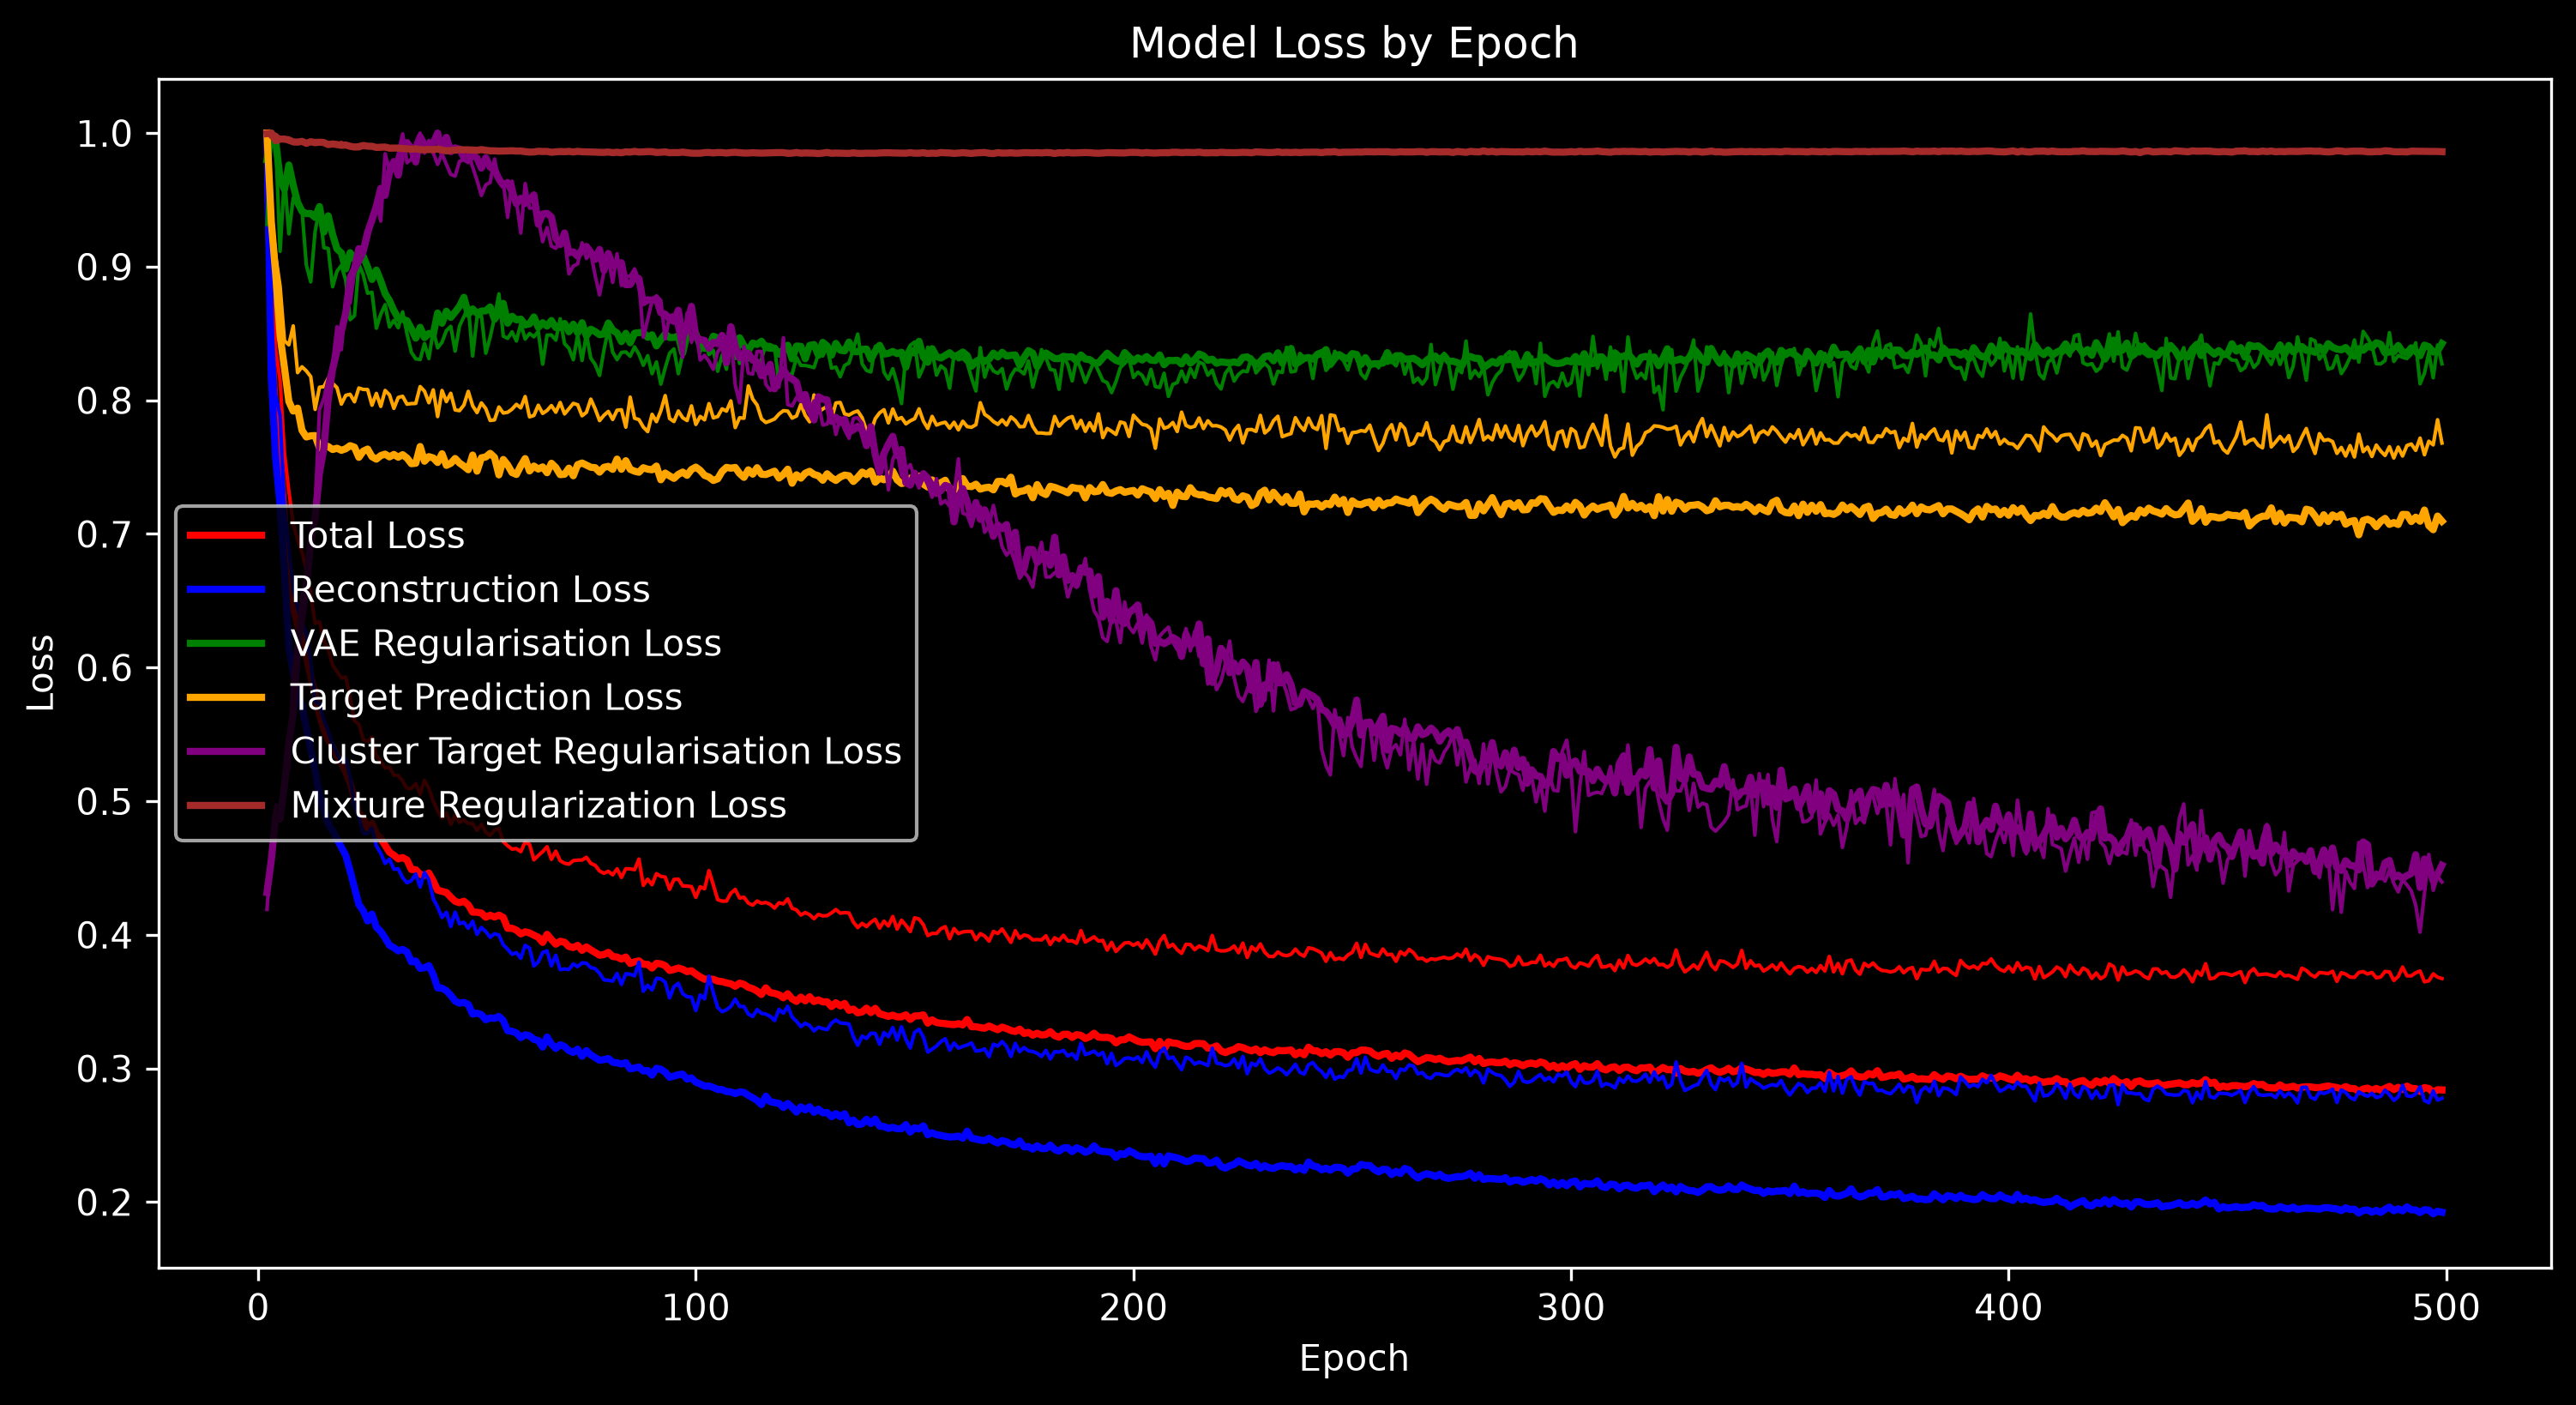

In [16]:
utils.plot_all_losses(history=history)

## Cross validation

In [ ]:
cross_validator = CrossValidator(vae=vae,filepath=results_path,cluster_number=cluster_number,n_runs=10)
histories = cross_validator.run(X=z500.values,y=label_indices,epochs=epochs, batch_size=batch_size)

Epoch 1/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - cluster_target_regularisation_loss: 0.2236 - mixture_regularization_loss: 5.8820 - reconstruction_loss: 474.5729 - target_prediction_loss: 6.0457 - total_loss: 501.7464 - vae_regularisation_loss: 15.0221 - val_cluster_target_regularisation_loss: 0.3599 - val_mixture_regularization_loss: 5.7306 - val_reconstruction_loss: 274.6365 - val_target_prediction_loss: 6.5940 - val_total_loss: 313.9054 - val_vae_regularisation_loss: 26.5844
Epoch 2/500
 1/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - cluster_target_regularisation_loss: 0.3857 - mixture_regularization_loss: 5.7212 - reconstruction_loss: 277.5606 - target_prediction_loss: 7.5317 - total_loss: 319.1956 - vae_regularisation_loss: 27.9965

/Users/qnicolas/miniforge3/envs/cmmvae/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 56 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - cluster_target_regularisation_loss: 0.3821 - mixture_regularization_loss: 5.6550 - reconstruction_loss: 252.0054 - target_prediction_loss: 6.1690 - total_loss: 288.1758 - vae_regularisation_loss: 23.9643 - val_cluster_target_regularisation_loss: 0.3784 - val_mixture_regularization_loss: 5.6024 - val_reconstruction_loss: 233.1217 - val_target_prediction_loss: 5.4464 - val_total_loss: 266.3007 - val_vae_regularisation_loss: 21.7517
Epoch 3/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - cluster_target_regularisation_loss: 0.4438 - mixture_regularization_loss: 5.6028 - reconstruction_loss: 230.6767 - target_prediction_loss: 5.5830 - total_loss: 263.9548 - vae_regularisation_loss: 21.6486 - val_cluster_target_regularisation_loss: 0.5234 - val_mixture_regularization_loss: 5.6076 - val_reconstruction_loss: 211.7197 - val_target_prediction_loss: 5.4973 - val_total_loss: 246.2761 - val_vae_regularisation_loss: 22.9281
Epoch 4/500
35/35 ━━━━━━━━━━━━━━━━━━━━

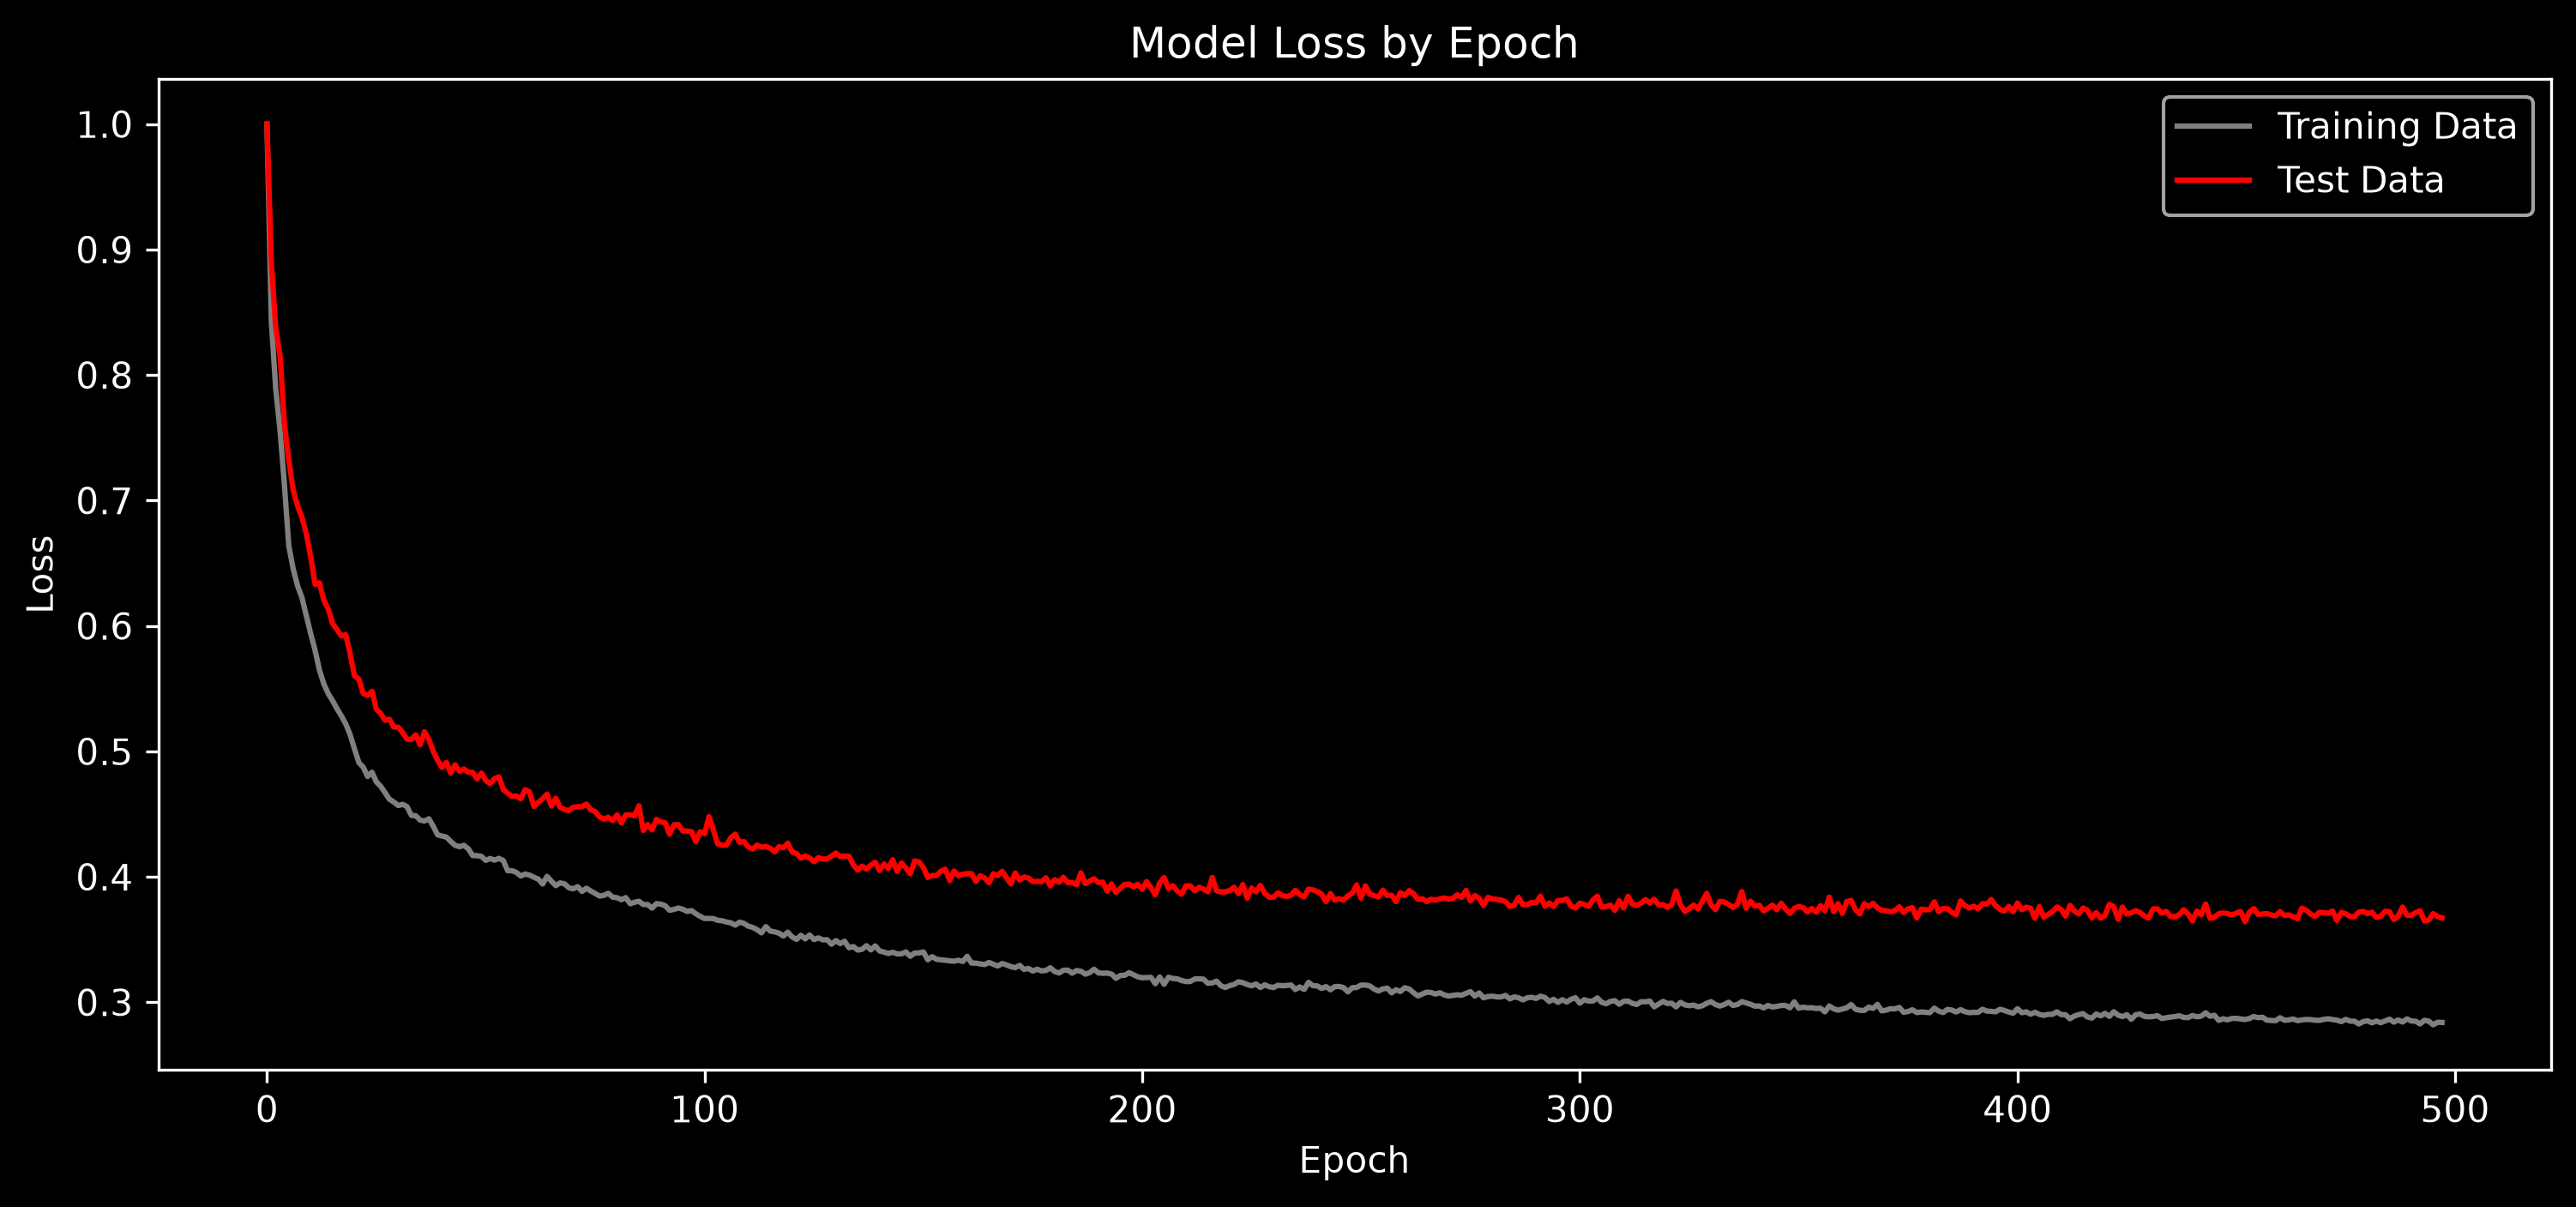

In [ ]:
number = 1

training_loss = histories[number].history['total_loss']
validation_loss = histories[number].history['val_total_loss']
utils.plot_losses(training_loss, validation_loss)

## Visualize clusters centers & target maps

In [6]:
cluster_number = 4

config = VAEConfig(
    original_dim=original_dim,
    original_dim_target=pr_cluster_number,
    dim_layer1=256,
    dim_layer2=128,
    dim_layer3=64,
    activation="relu",
    cluster_number=cluster_number,
    latent_dim=10,
    pr_cluster_number=pr_cluster_number,
    sampling_fn=sampling,
)

In [7]:
def make_plots(run_id):
    vae = VAEPredictor(cfg=config)
    if run_id==-1:
        weights_path = results_path + f"final_weights_{vae.cfg.cluster_number}.weights.h5"
    else:
        weights_path = results_path + f"final_weights_{vae.cfg.cluster_number}_{run_id}.weights.h5"
    vae.load_weights(weights_path)

    cluster_probabilities = predict_clusters(vae=vae, inputs=z500.values)
    cluster_labels = np.argmax(cluster_probabilities, axis=1)
    z500_with_label = z500.assign_coords(cluster=("time", cluster_labels))

    #order clusters by how often they occur in the data
    label_counts = np.bincount(z500_with_label.cluster.values)
    label_order = np.argsort(label_counts)[::-1]  # Sort in descending order

    fig_cluster_centers = eval_plots.plot_cluster_centers(
        vae,
        z500[0],
        plot_reordering=label_order,
        levels=np.arange(-2.0, 2.1, 0.25),
    )

    fig_empirical_cluster_centers = eval_plots.plot_empirical_cluster_centers(
        z500_with_label,
        plot_reordering=label_order,
        levels=np.arange(-2.0, 2.1, 0.25),
    )

    wind_energy_means = df_norm.groupby(z500_with_label.cluster.values).mean()

    column_labels = df_norm.columns.astype(str).tolist()

    plot_data_list = []
    for cluster_id in range(cluster_number):
        df_temp = pd.DataFrame({
            'iso2_labels': column_labels,  
            'metric_value': wind_energy_means.loc[cluster_id].values,
            'cluster': f"Regime {cluster_id}" 
        })
        plot_data_list.append(df_temp)

    # reorder plots
    plot_data_list = [plot_data_list[i] for i in label_order]

    df_plot = pd.concat(plot_data_list, ignore_index=True)

    cc = coco.CountryConverter()

    # Convert the ISO-2 labels column to ISO-3 strings
    df_plot['iso3_labels'] = cc.convert(names=df_plot['iso2_labels'].tolist(), to='ISO3')

    # Plot
    fig = px.choropleth(
        df_plot,
        locations="iso3_labels",        
        locationmode="ISO-3",         
        color="metric_value",         
        hover_name="iso2_labels",    
        scope="europe",               
        facet_col="cluster",         
        color_continuous_scale=px.colors.sequential.Viridis, 
        title="Wind CF Clusters"
    )


    fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1])) 
    fig.update_layout(
        margin={"r":10, "t":40, "l":10, "b":5},
        height=200, 
        width=600, 

        coloraxis_colorbar=dict(
            title="Wind CF anomaly",     # Label for the scale
            thicknessmode="pixels",
            thickness=5,  
            orientation="h",           # Thinner bar (default is usually 30)
            lenmode="fraction",
            len=0.5,                  # Takes up only 60% of the map height instead of 100%
            yanchor="middle",         # Centers it vertically
            y=-0.1
        )
    )
    fig.show()

199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 445us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


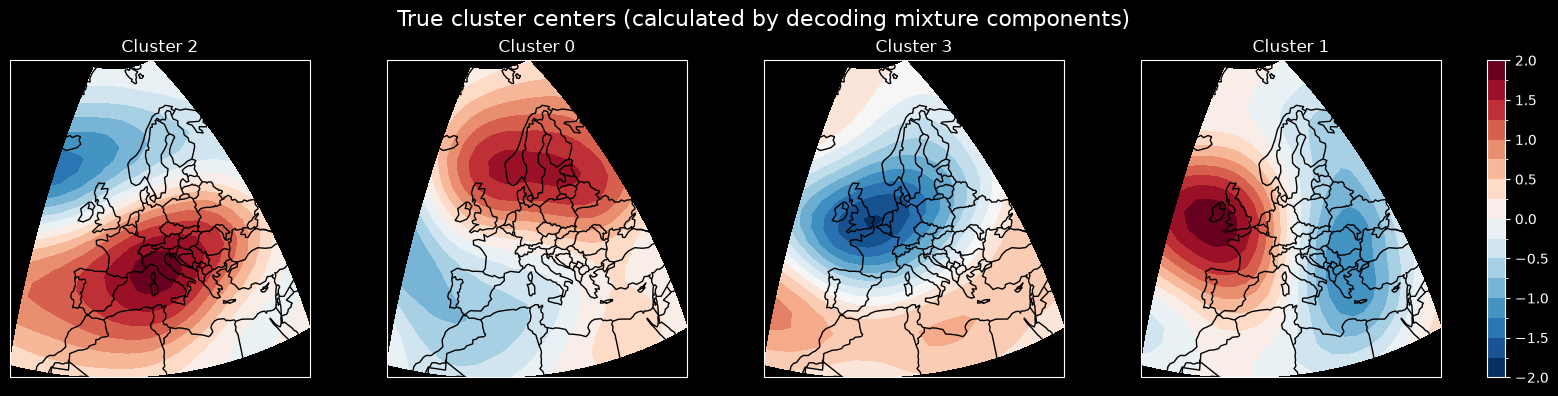

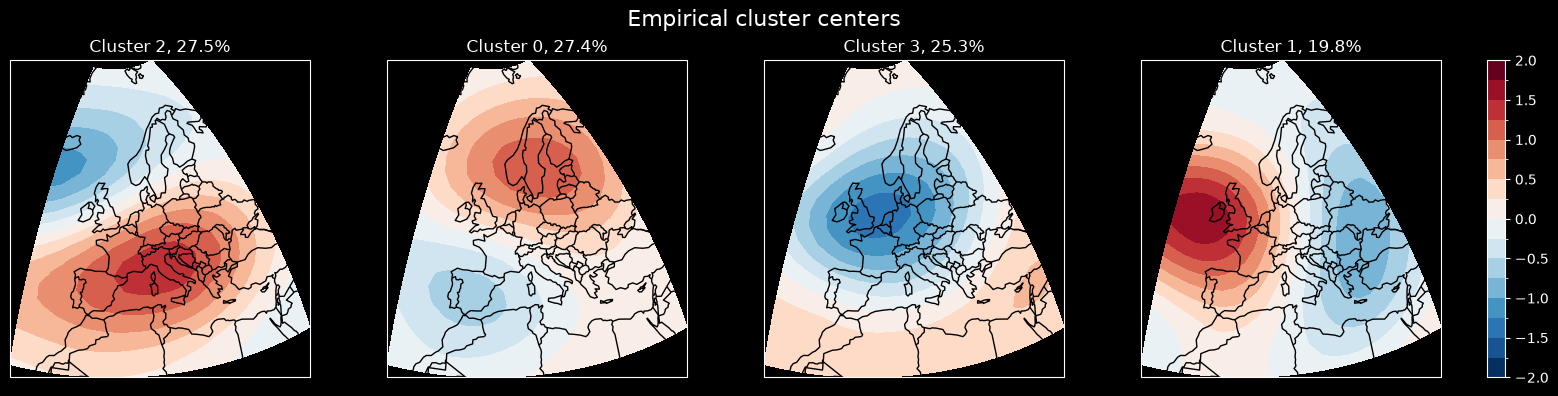

In [8]:
make_plots(0)

## Informativeness metrics

In [9]:
import matplotlib.pyplot as plt
def get_skill_scores(metric_func: callable, n_runs: int) -> np.ndarray:
    """Compute skill scores for various versions of the target variable.

    :param metric_func: Function to compute a skill score. It should take a VAEPredictor as input and return a float.
    :param n_runs: Number of runs to compute the skill scores for.
    :return: Array of Brier skill scores for each run.
    """
    vae = VAEPredictor(cfg=config)
    scores = []
    for run_id in range(n_runs):
        vae.load_weights(results_path + f"final_weights_{vae.cfg.cluster_number}_{run_id}.weights.h5")
        bss = metric_func(vae)
        scores.append(bss)
    return np.array(scores)

def get_skill_scores_for_all_metrics(n_runs: int = 10) -> np.ndarray:
    """Compute the Brier skill scores for precipitation clusters, 5th percentile exceedance, and precipitation terciles.

    :param n_runs: Number of runs to compute the skill scores for.
    :return: Array of Brier skill scores for each metric and each run.
    """
    metric_funcs = [lambda vae: metrics.compute_BSS_clusters_target(vae, z500.values, label_indices),
                    lambda vae: metrics.compute_BSS_quantile_exceedance(vae, z500.values, df_norm.values, q = 0.05, larger_than=False),
                    lambda vae: metrics.compute_BSS_quantile_prediction(vae, z500.values, df_norm.values, N = 3)
                    ]
    
    metric_names = ["Brier skill score\nfor precipitation clusters",
                     "Brier skill score\nfor being lower than 5th\npercentile per grid point",
                     "Brier skill score\nfor terciles per grid point"]
    
    n_metrics = len(metric_funcs)
    scores = np.zeros((n_metrics, n_runs))

    for metric_id in range(n_metrics):
        scores[metric_id] = get_skill_scores(metric_funcs[metric_id], n_runs)

    return scores, metric_names


In [10]:
scores, metric_names = get_skill_scores_for_all_metrics()

199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 436us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 306us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 291us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 290us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 309us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 293us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 316us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 311us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 318us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 310us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 432us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 330us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 775us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 295us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 298us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 298us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 295us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 290us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 283us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 302us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 416us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 297us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 296us/step
199/199 ━━━

(0.0, 0.25)

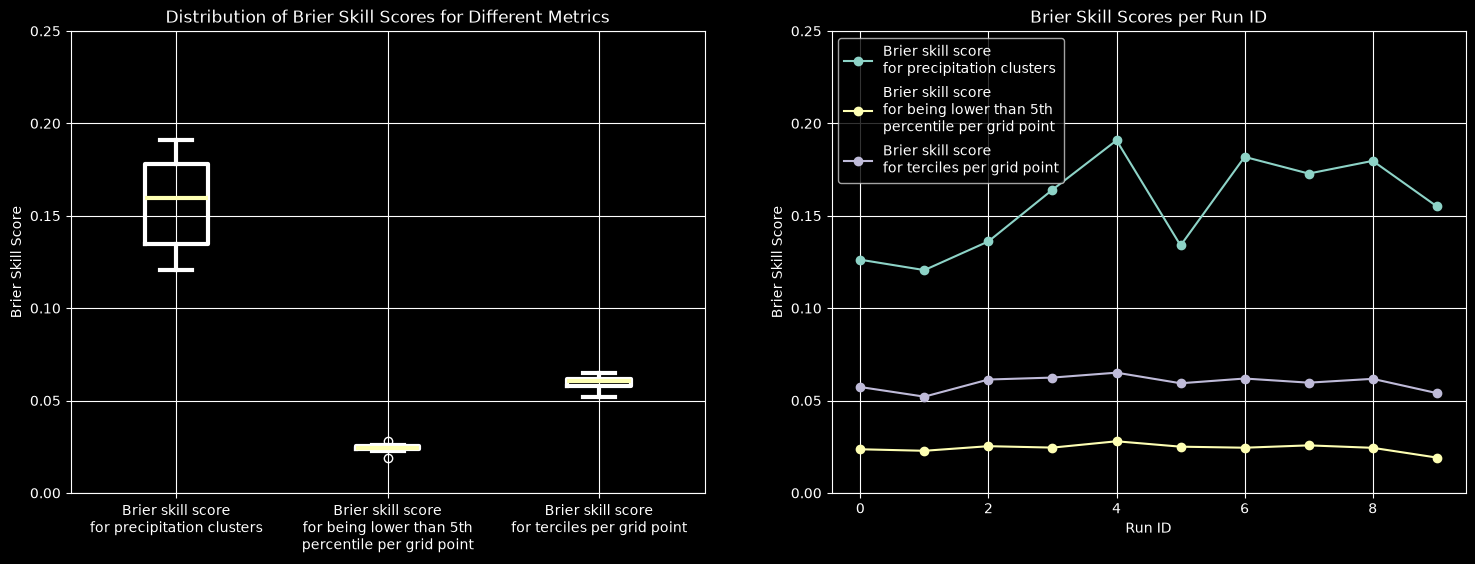

In [11]:
_, axs = plt.subplots(1, 2, figsize=(18, 6))

# Box and whisker plots
ax = axs[0]
props = dict(linewidth=3)
ax.boxplot(
    scores.T, 
    boxprops=props, 
    medianprops=props,
    whiskerprops=props,  # Thicker vertical lines
    capprops=props       # Thicker horizontal end caps
)
ax.set_xticklabels(metric_names, rotation=0, ha='center')
ax.set_title("Distribution of Brier Skill Scores for Different Metrics")
ax.set_ylabel("Brier Skill Score")
ax.set_ylim(0,0.25)
ax.grid()

# plots per run id
ax = axs[1]
for metric_id in range(scores.shape[0]):
    ax.plot(range(scores.shape[1]), scores[metric_id], marker='o', label=metric_names[metric_id])
ax.set_title("Brier Skill Scores per Run ID")
ax.set_xlabel("Run ID")
ax.set_ylabel("Brier Skill Score")
ax.grid()
ax.legend()
ax.set_ylim(0,0.25)